<a href="https://colab.research.google.com/github/projet-virage/ActiveTransportation/blob/main/ABM_ActiveTransportation_LowComplexity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Latest Version of the Agent-Based Transportation Model: GitHub–Google Colab Integration and Synchronization Workflow

In [ ]:
!pip install mesa
!pip install osmnx
!pip install optuna

In [3]:
from mesa import Model, Agent
from mesa.datacollection import DataCollector
from mesa.time import Schedule
import os

import geopandas as gpd
import networkx as nx
import osmnx
import numpy as np
import random
from shapely.geometry import Point
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.optimize import differential_evolution
import pandas as pd
from matplotlib.patches import Patch
import matplotlib.pyplot as plt
import time
import optuna

# Importing spatial data and preprocessing them

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
data_path = os.environ.get("DATA_FOLDER", "/content/drive/MyDrive/Transportation_UrbanHealth")
gender = pd.read_csv(os.path.join(data_path, "Gender.csv")).drop(columns=['Population']).dropna().reset_index(drop=True)
MTL_DA = gpd.read_file(os.path.join(data_path, "DA_MTL_MTM.shp"))
schools = gpd.read_file(os.path.join(data_path, "Schools_MTM.shp"))
residential = gpd.read_file(os.path.join(data_path, "Residential_MTM.shp"))
workplaces = gpd.read_file(os.path.join(data_path, "workplaces.shp"))
bixi = gpd.read_file(os.path.join(data_path, "Bixi_station_MTM.shp"))
stm = gpd.read_file(os.path.join(data_path, "STM_MTM.shp"))
Netnodes = gpd.read_file(os.path.join(data_path, "Nodes.shp"))
Netedges_car = gpd.read_file(os.path.join(data_path, "Edges_car.shp")).set_index(['u', 'v', 'key'])
Netedges_walk = gpd.read_file(os.path.join(data_path, "Edges_walk.shp")).set_index(['u', 'v', 'key'])
Netedges_bike = gpd.read_file(os.path.join(data_path, "Edges_bike.shp")).set_index(['u', 'v', 'key'])
Netedges_transit = gpd.read_file(os.path.join(data_path, "Edges_transit.shp")).set_index(['u', 'v', 'key'])

In [6]:
# Preprocessing the DA data
gender[['Male',	'Female']] = gender[['Male',	'Female']].apply(lambda x: x/(gender['Male'] + gender['Female']))
MTL_DA = MTL_DA[['UID_12','Population', 'Income_1', 'Car_1','Transit_1', 'Walk_1','Bike_1','geometry']].rename(columns={'UID_12':'DA_name','Income_1':'Income','Car_1':'Car','Transit_1':'Transit','Walk_1':'Walk','Bike_1':'Bike'})
MTL_DA['All_modes']=MTL_DA['Car']+MTL_DA['Transit']+MTL_DA['Walk']+MTL_DA['Bike']
montreal_da = MTL_DA.merge(gender, on="DA_name", how= 'right').copy()
montreal_da['Area'] = montreal_da.geometry.area / 1000000 # Area in Km2
montreal_da['pop_dens'] = montreal_da['Population'] / montreal_da['Area']

# Creating Networks

In [7]:
nodex = Netnodes.join(Netnodes.get_coordinates()).set_index('nodeid')[['x', 'y', 'geometry']]

# Load network
netx_car = osmnx.graph_from_gdfs(nodex, Netedges_car)
netx_walk = osmnx.graph_from_gdfs(nodex, Netedges_walk)
netx_bike = osmnx.graph_from_gdfs(nodex, Netedges_bike)
netx_transit = osmnx.graph_from_gdfs(nodex, Netedges_transit)

# Plotting Network

In [ ]:
# Car network
fig, ax = osmnx.plot.plot_graph(netx_car, edge_alpha=.3, node_color="r", node_size=5, node_zorder=0, node_alpha=.2)

# Walk network
fig, ax = osmnx.plot.plot_graph(netx_walk, edge_alpha=.3, node_color="r", node_size=4, node_zorder=0, node_alpha=.2)

# Bike network
fig, ax = osmnx.plot.plot_graph(netx_bike, edge_alpha=.3, node_color="r", node_size=4, node_zorder=0, node_alpha=.2)

# Transit network
fig, ax = osmnx.plot.plot_graph(netx_transit, edge_alpha=.3, node_color="r", node_size=4, node_zorder=0, node_alpha=.2)

# Model development

In [8]:
# The main function
class TransportModel(Model):

  def __init__(self, n_rep, DA_MTL, Res, Net_car, Net_walk, Net_bike, Net_transit, Wrk_N, Schls_N, BiXi_N, STM_N):
    super().__init__()
    self.agent_list = []
    self.Each_agent_represents = n_rep
    self.montreal_da = DA_MTL
    self.residential = Res
    self.betas = None

    schools_with_da = gpd.sjoin(Schls_N, self.montreal_da[["DA_name", "geometry"]], how="left", predicate="intersects")

    self.Gc = Net_car
    self.Gw = Net_walk
    self.Gb = Net_bike
    self.Gstm = Net_transit

    self.workplaces = Wrk_N
    self.schools = schools_with_da
    self.bixis_Gb = BiXi_N.copy()
    self.bixis_Gw = BiXi_N.copy()
    self.stms_Gstm = STM_N.copy()
    self.stms_Gw = STM_N.copy()

    self.car_cache = {}
    self.walk_cache = {}
    self.transit_cache = {}
    self.bike_cache = {}
    # Add network nodes

    self.bixis_Gb['network_node'] = osmnx.distance.nearest_nodes(self.Gb, self.bixis_Gb.geometry.x, self.bixis_Gb.geometry.y)
    self.bixis_Gw['network_node'] = osmnx.distance.nearest_nodes(self.Gw, self.bixis_Gw.geometry.x, self.bixis_Gw.geometry.y)

    self.stms_Gstm['network_node'] = osmnx.distance.nearest_nodes(self.Gstm, self.stms_Gstm.geometry.x, self.stms_Gstm.geometry.y)
    self.stms_Gw['network_node'] = osmnx.distance.nearest_nodes(self.Gw, self.stms_Gw.geometry.x, self.stms_Gw.geometry.y)

    self.bixi_tree_Gb = cKDTree(np.column_stack([self.bixis_Gb.geometry.x, self.bixis_Gb.geometry.y]))
    self.bixi_tree_Gw = cKDTree(np.column_stack([self.bixis_Gw.geometry.x, self.bixis_Gw.geometry.y]))
    self.stm_tree_Gstm = cKDTree(np.column_stack([self.stms_Gstm.geometry.x, self.stms_Gstm.geometry.y]))
    self.stm_tree_Gw = cKDTree(np.column_stack([self.stms_Gw.geometry.x, self.stms_Gw.geometry.y]))

    #----------------------------------------------------------------------
    # Residential
    self.residential["res_id"] = np.arange(len(self.residential))

    x = self.residential.centroid.x.values
    y = self.residential.centroid.y.values

    self.residential["node_Gc"] = osmnx.distance.nearest_nodes(self.Gc, x, y)
    self.residential["node_Gw"] = osmnx.distance.nearest_nodes(self.Gw, x, y)
    self.residential["node_Gb"] = osmnx.distance.nearest_nodes(self.Gb, x, y)
    self.residential["node_Gstm"] = osmnx.distance.nearest_nodes(self.Gstm, x, y)

    self.res_lookup = (self.residential.set_index("res_id")[["node_Gc","node_Gw","node_Gb","node_Gstm"]].to_dict("index"))

    #----------------------------------------------------------------------
    # Workplaces
    self.workplaces["wrk_id"] = np.arange(len(self.workplaces))

    xw = self.workplaces.geometry.x.values
    yw = self.workplaces.geometry.y.values

    self.workplaces["node_Gc"] = osmnx.distance.nearest_nodes(self.Gc, xw, yw)
    self.workplaces["node_Gw"] = osmnx.distance.nearest_nodes(self.Gw, xw, yw)
    self.workplaces["node_Gb"] = osmnx.distance.nearest_nodes(self.Gb, xw, yw)
    self.workplaces["node_Gstm"] = osmnx.distance.nearest_nodes(self.Gstm, xw, yw)

    self.wrk_lookup = (self.workplaces.set_index("wrk_id")[["node_Gc","node_Gw","node_Gb","node_Gstm"]].to_dict("index"))
    #----------------------------------------------------------------------
    self.schools["school_id"] = np.arange(len(self.schools))

    xs = self.schools.centroid.x.values
    ys = self.schools.centroid.y.values

    self.schools["node_Gc"] = osmnx.distance.nearest_nodes(self.Gc, xs, ys)
    self.schools["node_Gw"] = osmnx.distance.nearest_nodes(self.Gw, xs, ys)
    self.schools["node_Gb"] = osmnx.distance.nearest_nodes(self.Gb, xs, ys)
    self.schools["node_Gstm"] = osmnx.distance.nearest_nodes(self.Gstm, xs, ys)

    self.school_lookup = (self.schools.set_index("school_id")[["node_Gc","node_Gw","node_Gb","node_Gstm"]].to_dict("index"))
    #-----------------------------------------------------------------------------------------
    # Create agents
    self.create_agents()


    # Data collection
    self.datacollector = DataCollector(
        agent_reporters={
            "DA_ID": "DA_ID",
            "age": "age",
            "gender": "gender", # 0 represents female/woman and 1 represents male/man
            "income": "income",
            "time_home_work_car": "time_home_work_car",
            "time_home_stm": "time_home_stm",
            "time_stm_stm": "time_stm_stm",
            "time_stm_work": "time_stm_work",
            "time_home_bixi": "time_home_bixi",
            "time_bixi_bixi": "time_bixi_bixi",
            "time_bixi_work": "time_bixi_work",
            "time_home_work_walk": "time_home_work_walk",
            "mode_choice": "mode_choice"
        }
    )

    # Activate agents in random order
    for agentt in tqdm(random.sample(self.agent_list, len(self.agent_list)), desc= "Agents activation"):
      agentt.step()

    self.compute_all_travel_times(self.agent_list)
    self.datacollector.collect(self)

  def closest_candidate_node(self, G, source_node, candidate_gdf, tree):

    source_xy = (
        G.nodes[source_node]['x'],
        G.nodes[source_node]['y']
    )

    distance, idx = tree.query(source_xy)
    return candidate_gdf.iloc[idx]['network_node']

  # --------------------------------------------------------
  def create_agents(self):

    pbar = tqdm(self.montreal_da.iterrows(), total=len(self.montreal_da))
    for _, da in pbar:
      pbar.set_description(f"Creating agents for DA: {da['DA_name']}")

      if da['Car'] == 0 and da['Transit'] == 0 and da['Bike'] == 0 and da['Walk'] == 0:
        continue

      else:
        # Residential polygons inside this DA
        res = self.residential[self.residential.intersects(da.geometry)]
        if res.empty:
          continue

        income_val = 0
        # Handle income with zero
        if da['Income'] != 0:
            income_val = da['Income']
        else:
            income_val = self.montreal_da[self.montreal_da['Income'] > 0]['Income'].median()

        # Initializing Adults (15–64)

        num_adults = round((da['Car'] / self.Each_agent_represents)) + round((da['Transit'] / self.Each_agent_represents))+ round((da['Bike'] / self.Each_agent_represents)) + round((da['Walk'] / self.Each_agent_represents))

        male_num = round(da['Male'] * num_adults)
        female_num = num_adults - male_num

        # Male initialization
        for _ in range(male_num):

          poly = res.iloc[[np.random.randint(len(res))]]

          agent = PersonAgent(self, {
              'age': random.randint(15, 64),
              'gender': 1,
              'age_group': 'adult',
              'DA_ID': da['DA_name'],
              'income': income_val,
              'res_id': poly['res_id'].values[0],
              'pop_dens': da['pop_dens'] # Agent is initialized in a DA with a population density of  pop_dens
              })

          self.agent_list.append(agent)

        # Female initialization
        for _ in range(female_num):
          poly = res.iloc[[np.random.randint(len(res))]]

          agent = PersonAgent(self, {
              'age': random.randint(15, 64),
              'gender': 0,
              'age_group': 'adult',
              'DA_ID': da['DA_name'],
              'income': income_val,
              'res_id': poly['res_id'].values[0],
              'pop_dens': da['pop_dens']
          })

          self.agent_list.append(agent)


  def compute_mode_shares(self): # This function is defined to be used only in model calibration

    results = {}

    for _, row in self.montreal_da.iterrows():

      if row['Car'] == 0 and row['Transit'] == 0 and row['Bike'] == 0 and row['Walk'] == 0: # Opting out the DA with no people using any four transportation modes (i.e., outliers)
        continue

      res = self.residential[self.residential.intersects(row.geometry)]
      if res.empty:
        continue

      da_id = row['DA_name']

      agentss = [a for a in self.agent_list if a.age_group == "adult" and a.DA_ID == da_id]

      counts = {'auto':0, 'transit':0, 'bike':0, 'walk':0}

      for a in agentss:
        if a.mode_choice == "auto": counts['auto'] += 1
        elif a.mode_choice == "transit": counts['transit'] += 1
        elif a.mode_choice == "bike": counts['bike'] += 1
        else: counts['walk'] += 1

        results[da_id] = counts.copy()

    return results

  # ==============================================================
  def _batch_shortest(self, G, origins, destinations, weight, cache):

    results = np.empty(len(origins), dtype=float)

    missing = {}

    for i, (o, d) in enumerate(zip(origins, destinations)):

        key = (o, d)

        if key in cache:
            results[i] = cache[key]

        else:
            missing.setdefault(key, []).append(i)


    if len(missing) == 0:
        return results

    unique_origins = [k[0] for k in missing]
    unique_destinations = [k[1] for k in missing]

    # Single CPU environment
    paths = osmnx.routing.shortest_path(G,unique_origins,unique_destinations,weight=weight,cpus=1)

    for path, key in zip(paths, missing.keys()):

        if path is None:
            dist = np.nan
        else:
            dist = nx.path_weight(
                G,
                path,
                weight=weight
            )

        cache[key] = dist

        for idx in missing[key]:
            results[idx] = dist


    return results

  # ==============================================================
  def compute_all_travel_times(self, agents):
    # CAR: home -----> work

    t0 = time.perf_counter()
    total_steps = 4
    stp = 1
    print(f"[{stp}/{total_steps}] Computing car travel times...")

    car_times = self._batch_shortest(self.Gc, [a.home_node_Gc for a in agents], [a.workplace_node_Gc for a in agents],"trv_time", self.car_cache)

    for a, t in zip(agents, car_times):
        a.time_home_work_car = t
        a.auto_available = np.isfinite(t)

    print(f"Done ({time.perf_counter() - t0:.1f} s)")
    #--------------------------------------------------------------------------------------------------------------------

    t1 = time.perf_counter()
    stp += 1
    print(f"[{stp}/{total_steps}] Computing walking travel times...")
    # ---------- WALK: home -> work ----------
    walk_times = self._batch_shortest(self.Gw,[a.home_node_Gw for a in agents],[a.workplace_node_Gw for a in agents],"trv_time", self.walk_cache)

    for a, t in zip(agents, walk_times):
      a.time_home_work_walk = t
      a.walk_available = np.isfinite(t)

    print(f"Done ({time.perf_counter() - t1:.1f} s)")


    #-----------------------------------------------------------------------------------------------------------------
    t2 = time.perf_counter()
    stp += 1
    print(f"[{stp}/{total_steps}] Computing STM travel times...")
    # ---------- STM: home -> home_stm_node ----------
    home_stm_times = self._batch_shortest(self.Gw,[a.home_node_Gw for a in agents],[a.home_stm_node_Gw for a in agents],"trv_time", self.walk_cache)

    # Keep only agents with reachable home -> STM
    valid_agents = []

    for a, t in zip(agents, home_stm_times):
      a.time_home_stm = t
      a.transit_available = False   # default

      if np.isfinite(t):
        valid_agents.append(a)

    # ==============================================================
    #---------- STM: home_stm_node -> work_stm_node ----------
    if len(valid_agents) > 0:
      stm_stm_times = self._batch_shortest(self.Gstm,[a.home_stm_node_Gstm for a in valid_agents],[a.work_stm_node_Gstm for a in valid_agents],"trv_time", self.transit_cache)

      valid_agents_2 = []

      for a, t in zip(valid_agents, stm_stm_times):
        a.time_stm_stm = t

        if np.isfinite(t):
          valid_agents_2.append(a)

    # ---------- STM: work_stm_node -> workplace ----------
    if len(valid_agents_2) > 0:

      stm_work_times = self._batch_shortest(self.Gw,[a.work_stm_node_Gw for a in valid_agents_2],[a.workplace_node_Gw for a in valid_agents_2],"trv_time", self.walk_cache)

      for a, t in zip(valid_agents_2, stm_work_times):
        a.time_stm_work = t

        if np.isfinite(t):
          a.transit_available = True

    print(f"Done ({time.perf_counter() - t2:.1f} s)")

    #-----------------------------------------------------------------------------------------------------------------


    t3 = time.perf_counter()
    stp += 1
    print(f"[{stp}/{total_steps}] Computing BIXI travel times...")
    # ---------- BIXI: home -> home_bixi_node ----------
    home_bixi_times = self._batch_shortest(self.Gw,[a.home_node_Gw for a in agents],[a.home_bixi_node_Gw for a in agents],"trv_time", self.walk_cache)

    valid_agents_bixi = []

    for a, t in zip(agents, home_bixi_times):
      a.time_home_bixi = t
      a.bike_available = False

      if np.isfinite(t):
        valid_agents_bixi.append(a)


    if len(valid_agents_bixi) > 0:
      # ---------- BIXI: home_bixi_node -> work_bixi_node (time & length) ----------
      bixi_bixi_times = self._batch_shortest(self.Gb,[a.home_bixi_node_Gb for a in valid_agents_bixi],[a.work_bixi_node_Gb for a in valid_agents_bixi],"trv_time", self.bike_cache)

      valid_agents_bixi_2 = []
      for a, t in zip(valid_agents_bixi, bixi_bixi_times):
        a.time_bixi_bixi = t

        if np.isfinite(t):
          valid_agents_bixi_2.append(a)

    if len(valid_agents_bixi_2) > 0:
      # ---------- BIXI: work_bixi_node -> workplace ----------
      bixi_work_times = self._batch_shortest(self.Gw,[a.work_bixi_node_Gw for a in valid_agents_bixi_2],[a.workplace_node_Gw for a in valid_agents_bixi_2],"trv_time", self.walk_cache)

      for a, t in zip(valid_agents_bixi_2, bixi_work_times):
        a.time_bixi_work = t

        if np.isfinite(t):
          a.bike_available = True

    print(f"Done ({time.perf_counter() - t3:.1f} s)")


  def step(self):
    agent_df = self.datacollector.get_agent_vars_dataframe()

    agent_df["time_auto"] = agent_df["time_home_work_car"]
    agent_df["time_transit"] = agent_df["time_home_stm"] + agent_df["time_stm_stm"] + agent_df["time_stm_work"]
    agent_df["time_bike"] = agent_df["time_home_bixi"] + agent_df["time_bixi_bixi"] + agent_df["time_bixi_work"]
    agent_df["time_walk"] = agent_df["time_home_work_walk"]

    all_times = np.array([])
    all_times = np.concatenate([agent_df["time_auto"],agent_df["time_transit"],agent_df["time_bike"],agent_df["time_walk"]], axis = 0)

    for agent in self.agent_list:
      agent.compute_mode_choice(self.betas, agent_df, all_times)


In [9]:
class PersonAgent(Agent):

  def __init__(self, model, attrs):
    super().__init__(model)
    # Demographic
    self.age = attrs['age']
    self.age_group = attrs['age_group']
    self.gender = attrs['gender']
    self.DA_ID = attrs['DA_ID']
    self.income = attrs.get('income', None)
    self.res_id = attrs['res_id']
    self.work_id = None

    # Network home nodes

    self.home_node_Gc = None
    self.home_node_Gw = None
    self.home_node_Gb = None
    self.home_node_Gstm = None

    # Network workplace nodes

    self.workplace_node_Gc = None
    self.workplace_node_Gw = None
    self.workplace_node_Gb = None
    self.workplace_node_Gstm = None

    # Destinations
    self.home_bixi_node_Gw = None
    self.home_bixi_node_Gb = None
    self.work_bixi_node_Gw = None
    self.work_bixi_node_Gb = None

    self.home_stm_node_Gw = None
    self.home_stm_node_Gstm = None
    self.work_stm_node_Gw = None
    self.work_stm_node_Gstm = None


    # Travel times under different transportation modes
    self.time_home_work_car = np.nan
    self.time_home_stm = np.nan
    self.time_stm_stm = np.nan
    self.time_stm_work = np.nan
    self.time_home_bixi = np.nan
    self.time_bixi_bixi = np.nan
    self.time_bixi_work = np.nan
    self.time_home_work_walk = np.nan

    # Overal time for each mode
    self.time_auto = np.nan
    self.time_transit = np.nan
    self.time_bike = np.nan
    self.time_walk = np.nan


    # Availability of the transportation mode
    self.auto_available = False
    self.walk_available = False
    self.transit_available = False
    self.bike_available = False


    # Mode
    self.mode_choice = None
  # --------------------------------------------------------
  def step(self):
    self.assign_nodes()

  # --------------------------------------------------------
  def assign_nodes(self):

    home = self.model.res_lookup[self.res_id]

    self.home_node_Gc = home["node_Gc"]
    self.home_node_Gw = home["node_Gw"]
    self.home_node_Gb = home["node_Gb"]
    self.home_node_Gstm = home["node_Gstm"]

    # WORKPLACE (adults)
    if self.age_group == "adult":
      w_node = self.model.workplaces.sample(n=1)
      self.work_id = w_node['wrk_id'].iloc[0]
      wrk = self.model.wrk_lookup[self.work_id]

    # SCHOOL (children)
    else:
      if any(self.model.schools["DA_name"] == self.DA_ID):
        s_node = self.model.schools[self.model.schools["DA_name"] == self.DA_ID].sample(n=1)
      else:
        s_node = self.model.schools.sample(n=1)

      self.work_id = s_node['school_id'].iloc[0]
      wrk = self.model.school_lookup[self.work_id]

    self.workplace_node_Gc = wrk["node_Gc"]
    self.workplace_node_Gw = wrk["node_Gw"]
    self.workplace_node_Gb = wrk["node_Gb"]
    self.workplace_node_Gstm = wrk["node_Gstm"]

    # STM candidate nodes (nearest-neighbor lookups)
    self.home_stm_node_Gstm = self.model.closest_candidate_node(self.model.Gstm, self.home_node_Gstm, self.model.stms_Gstm, self.model.stm_tree_Gstm)
    self.work_stm_node_Gstm = self.model.closest_candidate_node(self.model.Gstm, self.workplace_node_Gstm, self.model.stms_Gstm, self.model.stm_tree_Gstm)
    self.home_stm_node_Gw = self.model.closest_candidate_node(self.model.Gw, self.home_node_Gw, self.model.stms_Gw, self.model.stm_tree_Gw)
    self.work_stm_node_Gw = self.model.closest_candidate_node(self.model.Gw, self.workplace_node_Gw, self.model.stms_Gw, self.model.stm_tree_Gw)

    # BIXI candidate nodes
    self.home_bixi_node_Gb = self.model.closest_candidate_node(self.model.Gb, self.home_node_Gb, self.model.bixis_Gb, self.model.bixi_tree_Gb)
    self.work_bixi_node_Gb = self.model.closest_candidate_node(self.model.Gb, self.workplace_node_Gb, self.model.bixis_Gb, self.model.bixi_tree_Gb)
    self.home_bixi_node_Gw = self.model.closest_candidate_node(self.model.Gw, self.home_node_Gw, self.model.bixis_Gw, self.model.bixi_tree_Gw)
    self.work_bixi_node_Gw = self.model.closest_candidate_node(self.model.Gw, self.workplace_node_Gw, self.model.bixis_Gw, self.model.bixi_tree_Gw)

  # --------------------------------------------------------
  def compute_mode_choice(self, betas, df, all_times):
    (
    β1,   # time_auto
    β2,   # age_auto
    β3,   # gender
    β4,   # income_auto
    β5,   # age × time_auto
    β6,   # income × time_auto

    β7,   # time_transit
    β8,   # age_transit
    β9,   # gender
    β10,   # income_transit
    β11,   # age × time_transit
    β12,  # income × time_transit

    β13,  # time_bike
    β14,  # age_bike
    β15,  # gender
    β16,  # income_bike
    β17,  # age × time_bike
    β18,  # income × time_bike

    β19,  # time_walk
    β20,  # age_walk
    β21,   # gender
    β22,  # income_walk
    β23,  # age × time_walk
    β24,  # income × time_walk

    ASC_auto,
    ASC_transit,
    ASC_bike) = betas

    # Z-score standardization
    ###########################################################

    def safe_standardize(value, series):

        series = np.asarray(series, dtype=float)
        series = series[np.isfinite(series)]

        if len(series) == 0:
            return 0.0

        mean = np.mean(series)
        std = np.std(series)

        if std == 0:
            return 0.0

        if pd.isna(value):
            return np.nan

        return (value - mean) / std

    time_auto = self.time_home_work_car
    time_transit = self.time_home_stm + self.time_stm_stm + self.time_stm_work
    time_bike = self.time_home_bixi + self.time_bixi_bixi + self.time_bixi_work
    time_walk = self.time_home_work_walk

    time_auto = safe_standardize(time_auto, df["time_home_work_car"])

    time_transit = safe_standardize(time_transit,df["time_home_stm"] +df["time_stm_stm"] +df["time_stm_work"])

    time_bike = safe_standardize(time_bike,df["time_home_bixi"] +df["time_bixi_bixi"] +df["time_bixi_work"])

    time_walk = safe_standardize(time_walk,df["time_home_work_walk"])

    income = safe_standardize(self.income, df["income"])
    age = safe_standardize(self.age, df["age"])

    # Verifying if there is any Nan in the values
    if np.isnan(time_auto):
      self.auto_available = False
      U_auto = -np.inf

    if np.isnan(time_transit):
      self.transit_available = False
      U_transit = -np.inf

    if np.isnan(time_bike):
      self.bike_available = False
      U_bike = -np.inf

    if np.isnan(time_walk):
      self.walk_available = False
      U_walk = -np.inf

    # Utilities
    if self.auto_available == True:
      U_auto = (ASC_auto
                + β1 * time_auto
                + β2 * age
                + β3 * self.gender
                + β4 * income
                + β5 * age * time_auto
                + β6 * income * time_auto)
    else:
      U_auto = -np.inf

    if self.transit_available == True:
      U_transit = (
          ASC_transit
          + β7 * time_transit
          + β8 * age
          + β9 * self.gender
          + β10 * income
          + β11 * age * time_transit
          + β12 * income * time_transit)
    else:
      U_transit = -np.inf

    if self.bike_available == True:
      U_bike = (
          ASC_bike
        + β13 * time_bike
        + β14 * age
        + β15 * self.gender
        + β16 * income
        + β17 * age * time_bike
        + β18 * income * time_bike)
    else:
      U_bike = -np.inf

    if self.walk_available == True:
      U_walk = (
          β19 * time_walk
        + β20 * age
        + β21 * self.gender
        + β22 * income
        + β23 * age * time_walk
        + β24 * income * time_walk)
    else:
      U_walk = -np.inf

    # Calculation of probabilities
    utilities = np.array([U_auto, U_transit, U_bike, U_walk])

    exp_u = np.exp(utilities)
    sum_exp = np.sum(exp_u)

    modes = ["auto", "transit", "bike", "walk"]

    if sum_exp == 0 or np.isnan(sum_exp) or np.isinf(sum_exp):
      self.mode_choice = random.choice(["auto", "transit", "bike", "walk"])
    else:
      probs = exp_u / sum_exp
      self.mode_choice = modes[np.argmax(probs)]

#Considering each agent as the represener of 50 people

In [10]:
# Initialize the transport model
Transport_model = TransportModel(n_rep = 50, DA_MTL = montreal_da, Res = residential, Net_car = netx_car, Net_walk = netx_walk, Net_bike = netx_bike,  Net_transit= netx_transit, Wrk_N = workplaces, Schls_N = schools, BiXi_N= bixi, STM_N = stm)


Agents activation: 100%|██████████| 12372/12372 [12:57<00:00, 15.92it/s]


[1/4] Computing car travel times...
Done (801.9 s)
[2/4] Computing walking travel times...
Done (1087.9 s)
[3/4] Computing STM travel times...
Done (692.2 s)
[4/4] Computing BIXI travel times...
Done (766.9 s)


# Calibration

In [11]:
def calibration_error(betas, model, n_steps=5, save_results=False):

  # ============================================================
  # Run the model for n_steps
  # ============================================================
  # Give the model the current Optuna parameters
  model.betas = betas

  #for step in range(n_steps):
  model.step()

  sim = model.compute_mode_shares()

  total_error = 0.0
  total_weight = 0.0

  calibration_records = []

  observed_global = np.zeros(4)
  simulated_global = np.zeros(4)

  pbar = tqdm(model.montreal_da.iterrows(), total=len(model.montreal_da))

  for _, da in pbar:

      pbar.set_description(f"Calibrating DA: {da['DA_name']}")

      if (da["Car"] == 0 and da["Transit"] == 0 and da["Bike"] == 0 and da["Walk"] == 0):
          continue

      res = model.residential[model.residential.intersects(da.geometry)]

      if res.empty:
          continue

      da_id = da["DA_name"]

      if da_id not in sim:
          continue

      observed_counts = np.array([
          round(da["Car"] / model.Each_agent_represents),
          round(da["Transit"] / model.Each_agent_represents),
          round(da["Bike"] / model.Each_agent_represents),
          round(da["Walk"] / model.Each_agent_represents)
      ], dtype=float)

      simulated_counts = np.array([
          sim[da_id]["auto"],
          sim[da_id]["transit"],
          sim[da_id]["bike"],
          sim[da_id]["walk"]
      ], dtype=float)

      observed_global += observed_counts
      simulated_global += simulated_counts

      obs_total = observed_counts.sum()
      sim_total = simulated_counts.sum()

      if obs_total == 0 or sim_total == 0:
          continue


      observed_share = observed_counts / obs_total
      simulated_share = simulated_counts / sim_total

      share_error = np.mean((observed_share-simulated_share)**2)

      total_error += obs_total * share_error
      total_weight += obs_total

      calibration_records.append({

          "DA_name": da_id,

          "Obs_Auto": observed_counts[0],
          "Obs_Transit": observed_counts[1],
          "Obs_Bike": observed_counts[2],
          "Obs_Walk": observed_counts[3],

          "Sim_Auto": simulated_counts[0],
          "Sim_Transit": simulated_counts[1],
          "Sim_Bike": simulated_counts[2],
          "Sim_Walk": simulated_counts[3],

          "Error": share_error,

      })

  # ============================================================
  # Global penalties
  # ============================================================

  if total_weight == 0:
      return np.inf

  local_error = total_error / total_weight

  obs_share_global = observed_global / observed_global.sum()
  sim_share_global = simulated_global / simulated_global.sum()

  global_share_error = np.mean((obs_share_global - sim_share_global)**2)

  final_error = (0.2 * local_error + 0.8 * global_share_error)

  # ============================================================
  # Save results
  # ============================================================

  if save_results:

    calibration_df = pd.DataFrame(calibration_records)

    calibration_df.to_csv("/content/drive/MyDrive/Transportation_UrbanHealth/DA_calibration_results.csv",index=False)

    df_updated = model.datacollector.get_agent_vars_dataframe()

    df_updated.to_csv("/content/drive/MyDrive/Transportation_UrbanHealth/Data_collecter_results.csv",index=False)

    print("\nObserved totals:")
    print(observed_global.astype(int))

    print("\nSimulated totals:")
    print(simulated_global.astype(int))

    print('Observed global: ', observed_global.sum())
    print('Simulated global: ', simulated_global.sum())

    print("\nObserved modal shares:")
    print(np.round(obs_share_global,3))

    print("\nSimulated modal shares:")
    print(np.round(sim_share_global,3))

    print("\nLocal error:", local_error)
    print("Global share error:", global_share_error)
    print("Final objective:", final_error)

    modes = ["Auto","Transit","Bike","Walk"]

    x = np.arange(len(modes))
    width = 0.35

    plt.figure(figsize=(8,6))

    plt.bar(x-width/2,observed_global,width,label="Observed")

    plt.bar(x+width/2,simulated_global,width,label="Simulated")

    plt.xticks(x,modes)

    plt.ylabel("Number of people")

    plt.title("Observed vs Simulated Transportation Modes")

    plt.grid(axis="y",alpha=0.3)

    plt.legend()

    plt.tight_layout()

    plt.show()

  return final_error

[I 2026-09-15 15:21:22,110] A new study created in memory with name: no-name-0dfd8c40-18dc-48c5-8866-f3725c082a66
Calibrating DA: 24663497: 100%|██████████| 3214/3214 [00:55<00:00, 57.65it/s]
[I 2026-09-15 15:23:46,468] Trial 0 finished with value: 0.18487463471878823 and parameters: {'β1': -1.269646768247643, 'β2': 1.3521429192297485, 'β3': 0.6959818254342154, 'β4': 0.2959754525911098, 'β5': -0.687962719115127, 'β6': -0.6880109593275947, 'β7': -1.886736956272011, 'β8': 1.0985284373248057, 'β9': 0.3033450352296265, 'β10': 0.6242177333881367, 'β11': -0.9588310114083951, 'β12': 0.9398197043239886, 'β13': -0.3767368504391777, 'β14': -0.8629826679651715, 'β15': -0.9545250983786981, 'β16': -0.9497864704396985, 'β17': -0.39151551408092455, 'β18': 0.04951286326447568, 'β19': -1.1577072136478743, 'β20': -0.6263125794058743, 'β21': 0.3355586841671383, 'β22': -1.0815184180438746, 'β23': -0.4157107029295637, 'β24': -0.2672763134126166, 'ASC_auto': -0.26358009469778443, 'ASC_transit': 3.2814076911


-----------------------------
Trial: 0
MSE: 0.184875
Betas:
[-1.26964677  1.35214292  0.69598183  0.29597545 -0.68796272 -0.68801096
 -1.88673696  1.09852844  0.30334504  0.62421773 -0.95883101  0.9398197
 -0.37673685 -0.86298267 -0.9545251  -0.94978647 -0.39151551  0.04951286
 -1.15770721 -0.62631258  0.33555868 -1.08151842 -0.4157107  -0.26727631
 -0.26358009  3.28140769 -3.40260974]


Calibrating DA: 24663497: 100%|██████████| 3214/3214 [00:55<00:00, 58.18it/s]
[I 2026-09-15 15:26:10,693] Trial 1 finished with value: 0.1621402685956882 and parameters: {'β1': -0.9972428450934574, 'β2': 0.2772437065861273, 'β3': -1.360648761840007, 'β4': 0.3226345557043151, 'β5': -0.6589517526254169, 'β6': -0.869896814029441, 'β7': -0.14967320235600012, 'β8': 1.396896099223678, 'β9': 0.9251920443493833, 'β10': -0.5861586924798879, 'β11': -0.8046557719872323, 'β12': 0.3684660530243138, 'β13': -1.1417026372077774, 'β14': -1.1338852954656635, 'β15': -0.014469269666189444, 'β16': -1.3968344366543448, 'β17': 0.8186408041575641, 'β18': -0.48244003679996617, 'β19': -0.7080815455097351, 'β20': -0.5648667717317671, 'β21': 0.06020406353343244, 'β22': 0.14013083802983894, 'β23': -0.6302910889489459, 'β24': 0.9391692555291171, 'ASC_auto': 1.6507969401666873, 'ASC_transit': 4.515991532513513, 'ASC_bike': 2.1586188034211906}. Best is trial 1 with value: 0.1621402685956882.



-----------------------------
Trial: 1
MSE: 0.162140
Betas:
[-0.99724285  0.27724371 -1.36064876  0.32263456 -0.65895175 -0.86989681
 -0.1496732   1.3968961   0.92519204 -0.58615869 -0.80465577  0.36846605
 -1.14170264 -1.1338853  -0.01446927 -1.39683444  0.8186408  -0.48244004
 -0.70808155 -0.56486677  0.06020406  0.14013084 -0.63029109  0.93916926
  1.65079694  4.51599153  2.1586188 ]


Calibrating DA: 24663497: 100%|██████████| 3214/3214 [00:55<00:00, 57.64it/s]
[I 2026-09-15 15:28:36,950] Trial 2 finished with value: 0.19934530977817383 and parameters: {'β1': -0.8340950413183841, 'β2': 1.2656227050693505, 'β3': -1.2345224938442416, 'β4': -0.9120514127425644, 'β5': -0.9095454221789239, 'β6': -0.3493393384734713, 'β7': -1.2420792851055102, 'β8': -0.6859529046783123, 'β9': 0.986212527455788, 'β10': -0.4297400199192323, 'β11': -0.4381309806252385, 'β12': 0.08539216631649693, 'β13': -1.7251977612992129, 'β14': 0.906590942262119, 'β15': -1.2763480689606874, 'β16': 1.4606608098015519, 'β17': 0.5444895385933148, 'β18': -0.6025686369316552, 'β19': -1.9892318716089754, 'β20': 0.9463842853645024, 'β21': 0.6205720315428511, 'β22': 0.6870215041229617, 'β23': 0.5425406933718915, 'β24': -0.8519106965318193, 'ASC_auto': -0.8492056287343646, 'ASC_transit': -2.0730475237989623, 'ASC_bike': 1.9048274070047482}. Best is trial 1 with value: 0.1621402685956882.


...


-----------------------------
Trial: 28
MSE: 0.036136
Betas:
[-0.15245489 -0.38574783  1.37821168  0.24353756  0.67843176  0.25239012
 -1.34096922 -0.90130272 -1.2014401   1.17428103  0.30882347  0.17062706
 -0.83558257  1.08162805 -0.71415759 -0.21968613 -0.36269656  0.08021553
 -0.6784901  -0.07791587  0.81508695  1.18004978  0.81337905  0.93732594
  0.76413218  2.22558732  0.39993888]


Calibrating DA: 24663497: 100%|██████████| 3214/3214 [00:57<00:00, 55.72it/s]
[I 2026-09-15 16:34:23,692] Trial 29 finished with value: 0.038600416502053564 and parameters: {'β1': -1.0203608864100273, 'β2': 0.2504304963322891, 'β3': 0.8293964972052377, 'β4': -0.5375459578229, 'β5': 0.5172182505712632, 'β6': -0.6774730241992684, 'β7': -1.0262472895463108, 'β8': -1.3752350847362838, 'β9': -0.14369353590775058, 'β10': 0.8237255945604313, 'β11': 0.23779013836310234, 'β12': -0.21882765569158913, 'β13': -0.27533863969440797, 'β14': 1.4437883958185582, 'β15': -0.7161552784085731, 'β16': -1.427305096214205, 'β17': -0.14441127836835355, 'β18': 0.24831376360507007, 'β19': -0.6420501645837766, 'β20': 0.4668394902268824, 'β21': -0.5729019493857253, 'β22': 0.4122107840108691, 'β23': 0.2650660651570341, 'β24': 0.7955687440207191, 'ASC_auto': 0.9660425300041375, 'ASC_transit': 1.7719372699011586, 'ASC_bike': -0.720780004324693}. Best is trial 25 with value: 0.021563575902746632.



-----------------------------
Trial: 29
MSE: 0.038600
Betas:
[-1.02036089  0.2504305   0.8293965  -0.53754596  0.51721825 -0.67747302
 -1.02624729 -1.37523508 -0.14369354  0.82372559  0.23779014 -0.21882766
 -0.27533864  1.4437884  -0.71615528 -1.4273051  -0.14441128  0.24831376
 -0.64205016  0.46683949 -0.57290195  0.41221078  0.26506607  0.79556874
  0.96604253  1.77193727 -0.72078   ]


Calibrating DA: 24663497: 100%|██████████| 3214/3214 [00:56<00:00, 56.55it/s]



Observed totals:
[7911 3483  161  817]

Simulated totals:
[6022 4986  911  453]
Observed global:  12372.0
Simulated global:  12372.0

Observed modal shares:
[0.639 0.282 0.013 0.066]

Simulated modal shares:
[0.487 0.403 0.074 0.037]

Local error: 0.06537015850311684
Global share error: 0.010652773374459544
Final objective: 0.021596250400191003


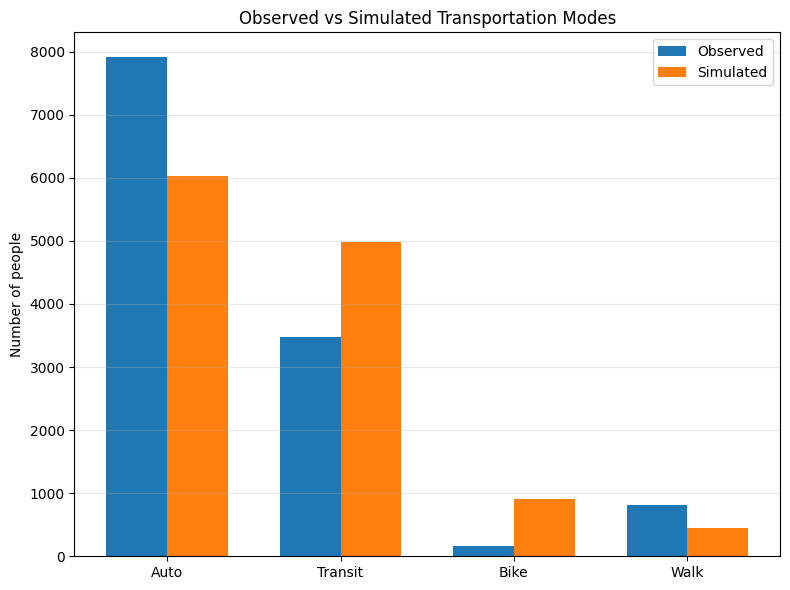


Optimization finished

Best MSE:
0.021563575902746632

Optimized coefficients:
[-0.85363171 -0.00754799  0.5659294  -0.33212493  0.50831502 -0.9353555
 -1.45569866 -0.81066167 -0.9076618   0.68805577 -0.17884152  0.26314412
 -0.50865955  1.2790285  -0.93138632 -0.96886887 -0.54890358  0.28164803
 -0.47449516  0.98384042 -0.17242277  0.35111888  0.46531109  0.7770375
  1.33385305  2.0073526  -0.40174886]


In [12]:
mse_history = []
beta_history = []


def objective(trial):

    betas = np.array([

    # =========================================================
    # AUTO
    # =========================================================

    trial.suggest_float("β1", -2.0, -0.05),   # time_auto
    trial.suggest_float("β2", -1.5,  1.5),    # age_auto
    trial.suggest_float("β3", -1.5,  1.5),    # gender_auto
    trial.suggest_float("β4", -1.5,  1.5),    # income_auto
    trial.suggest_float("β5", -1.0,  1.0),    # age × time_auto
    trial.suggest_float("β6", -1.0,  1.0),    # income × time_auto


    # =========================================================
    # TRANSIT
    # =========================================================

    trial.suggest_float("β7", -2.0, -0.05),   # time_transit
    trial.suggest_float("β8", -1.5,  1.5),    # age_transit
    trial.suggest_float("β9", -1.5, 1.5),    # gender_transit
    trial.suggest_float("β10", -1.5, 1.5),    # income_transit
    trial.suggest_float("β11", -1.0, 1.0),    # age × time_transit
    trial.suggest_float("β12", -1.0, 1.0),    # income × time_transit


    # =========================================================
    # BIKE
    # =========================================================

    trial.suggest_float("β13", -2.0, -0.05),  # time_bike
    trial.suggest_float("β14", -1.5, 1.5),    # age_bike
    trial.suggest_float("β15", -1.5, 1.5),    # gender_bike
    trial.suggest_float("β16", -1.5, 1.5),    # income_bike
    trial.suggest_float("β17", -1.0, 1.0),    # age × time_bike
    trial.suggest_float("β18", -1.0, 1.0),    # income × time_bike


    # =========================================================
    # WALK
    # =========================================================

    trial.suggest_float("β19", -2.0, -0.05),  # time_walk
    trial.suggest_float("β20", -1.5, 1.5),    # age_walk
    trial.suggest_float("β21", -1.5, 1.5),    # gender_walk
    trial.suggest_float("β22", -1.5, 1.5),    # income_walk
    trial.suggest_float("β23", -1.0, 1.0),    # age × time_walk
    trial.suggest_float("β24", -1.0, 1.0),    # income × time_walk


    # =========================================================
    # ASCs
    #
    # WALK = REFERENCE ALTERNATIVE
    # ASC_walk = 0
    # =========================================================

    trial.suggest_float("ASC_auto",    -3.0, 3.0),
    trial.suggest_float("ASC_transit", -3.0, 5.0),
    trial.suggest_float("ASC_bike",    -5.0, 3.0)
])


    # Run calibration
    mse = calibration_error(betas,Transport_model,n_steps=5,save_results=False)


    mse_history.append(mse)
    beta_history.append(betas)


    print("\n-----------------------------")
    print(f"Trial: {trial.number}")
    print(f"MSE: {mse:.6f}")

    print("Betas:")
    print(betas)


    return mse


# ============================================================
# Run Optuna
# ============================================================

study = optuna.create_study(direction="minimize",sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective,n_trials=30)


# ============================================================
# Extract best parameters
# ============================================================

best_params = study.best_params


optimized_betas = np.array([

    # Auto
    best_params["β1"],
    best_params["β2"],
    best_params["β3"],
    best_params["β4"],
    best_params["β5"],
    best_params["β6"],

    # Transit
    best_params["β7"],
    best_params["β8"],
    best_params["β9"],
    best_params["β10"],
    best_params["β11"],
    best_params["β12"],

    # Bike
    best_params["β13"],
    best_params["β14"],
    best_params["β15"],
    best_params["β16"],
    best_params["β17"],
    best_params["β18"],


    # Walk
    best_params["β19"],
    best_params["β20"],
    best_params["β21"],
    best_params["β22"],
    best_params["β23"],
    best_params["β24"],

    # ASCs
    best_params["ASC_auto"],
    best_params["ASC_transit"],
    best_params["ASC_bike"]
])


# ============================================================
# Evaluate best parameters
# ============================================================

best_mse = calibration_error(optimized_betas,Transport_model,n_steps=5,save_results=True)


print("\n==============================")
print("Optimization finished")
print("==============================")

print("\nBest MSE:")
print(study.best_value)

print("\nOptimized coefficients:")
print(optimized_betas)


# ============================================================
# Save coefficients
# ============================================================

np.save("/content/drive/MyDrive/Transportation_UrbanHealth/Betas_LowComplexity.npy",optimized_betas)

#Randomly changing agents' residential locations and workplaces

Number of agents changing their workplaces and residential places: 100%|██████████| 3711/3711 [04:16<00:00, 14.47it/s]


[1/4] Computing car travel times...
Done (223.2 s)
[2/4] Computing walking travel times...
Done (301.1 s)
[3/4] Computing STM travel times...
Done (190.8 s)
[4/4] Computing BIXI travel times...
Done (177.3 s)
Array of observed_counts:  [7911 3483  161  817]
Array of simulated_counts:  [5799 5179  952  442]
Sum of observed_counts:  12372
Sum of simulated_counts:  12372


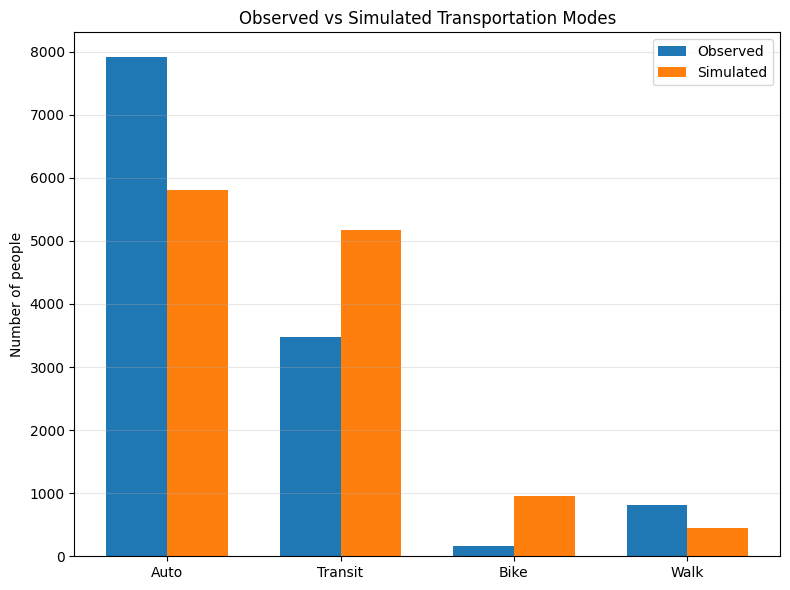

In [14]:
Optimized_betas = np.load("/content/drive/MyDrive/Transportation_UrbanHealth/Betas_LowComplexity.npy")

agents = Transport_model.agent_list
sample_size = int(0.30 * len(agents)) # 30% of agents

selected_agents = random.sample(agents, sample_size)

# Assigning new residential and workplaces
for agent in tqdm(selected_agents, desc="Number of agents changing their workplaces and residential places: "):
  new_res = Transport_model.residential.sample(n=1)
  agent.res_id = new_res['res_id'].iloc[0]
  agent.assign_nodes()

for step in range(1):
  Transport_model.compute_all_travel_times(selected_agents)

  agent_df = Transport_model.datacollector.get_agent_vars_dataframe()

  agent_df["time_auto"] = agent_df["time_home_work_car"]
  agent_df["time_transit"] = agent_df["time_home_stm"] + agent_df["time_stm_stm"] + agent_df["time_stm_work"]
  agent_df["time_bike"] = agent_df["time_home_bixi"] + agent_df["time_bixi_bixi"] + agent_df["time_bixi_work"]
  agent_df["time_walk"] = agent_df["time_home_work_walk"]

  all_times = np.concatenate([agent_df["time_auto"],agent_df["time_transit"],agent_df["time_bike"],agent_df["time_walk"]], axis = 0)

  for agent in selected_agents:
    agent.compute_mode_choice(Optimized_betas, agent_df, all_times)

  #Transport_model.agents_interactions_effect()


counts = {'auto':0, 'transit':0, 'bike':0, 'walk':0}

for a in agents:
  if a.mode_choice == "auto": counts['auto'] += 1
  elif a.mode_choice == "transit": counts['transit'] += 1
  elif a.mode_choice == "bike": counts['bike'] += 1
  else: counts['walk'] += 1

observed_counts = np.array([7911, 3483,  161,  817])
'''
observed_counts = np.array([
    round(Transport_model.montreal_da["Car"].sum() / Transport_model.Each_agent_represents),
    round(Transport_model.montreal_da["Transit"].sum() / Transport_model.Each_agent_represents),
    round(Transport_model.montreal_da["Bike"].sum() / Transport_model.Each_agent_represents),
    round(Transport_model.montreal_da["Walk"].sum() / Transport_model.Each_agent_represents)])
'''
simulated_counts = np.array([
    counts["auto"],
    counts["transit"],
    counts["bike"],
    counts["walk"]])


print('Array of observed_counts: ', observed_counts)
print('Array of simulated_counts: ', simulated_counts)

print('Sum of observed_counts: ', observed_counts.sum())
print('Sum of simulated_counts: ', simulated_counts.sum())


modes = ["Auto","Transit","Bike","Walk"]

x = np.arange(len(modes))
width = 0.35

plt.figure(figsize=(8,6))

plt.bar(x-width/2,observed_counts,width,label="Observed")

plt.bar(x+width/2,simulated_counts,width,label="Simulated")

plt.xticks(x,modes)

plt.ylabel("Number of people")

plt.title("Observed vs Simulated Transportation Modes")

plt.grid(axis="y",alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()